In [59]:
import pandas as pd
trades=pd.read_csv('fear_greed_index.csv')
sentiment = pd.read_csv('historical_data.csv')

Data PreProcessing

In [60]:
#Checking the null in dataset 
trades.isnull().sum().
sentiment.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [62]:
# Checking the duplicate in dataset 
trades.duplicated().sum()
sentiment.duplicated().sum()

np.int64(0)

In [74]:
# Matching the date of both the dataset
trades['date'] = pd.to_datetime(trades['timestamp'], unit='s').dt.date
sentiment['date'] = pd.to_datetime(sentiment['Timestamp'],unit='ms').dt.date

In [75]:
# Checking date range of both datasets to ensure they overlap
# This helps verify correct timestamp conversion and ensures proper merging
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2018-02-01 2025-05-02
2023-03-28 2025-06-15


In [81]:
# Converting timestamps into datetime format for both datasets
# 's' is used for trades (seconds) and 'ms' for sentiment (milliseconds)
# normalize() is used to remove time and keep only date for daily-level analysis and merging

trades['date'] = pd.to_datetime(trades['timestamp'], unit='s').dt.normalize()
sentiment['date'] = pd.to_datetime(sentiment['Timestamp'], unit='ms').dt.normalize()

In [96]:
# Merging trades and sentiment datasets on the 'date' column
# Left join is used to retain all trade records
merged_df = pd.merge(trades, sentiment, on='date', how='left')

In [97]:
# Checking for missing values after merging
merged_df['classification'].isnull().sum()

np.int64(0)

In [98]:
# Merging trades and sentiment datasets on 'date' using inner join
merged_df = pd.merge(trades, sentiment, on='date', how='inner')
len(merged_df)

184263

In [135]:
# Aggregating data daily: summing total PnL and assigning the most frequent sentiment per day
# This creates a clean dataset with one record per date for analysis

merged_daily = merged_df.groupby('date').agg({
    'Closed PnL': 'sum',
    'classification': lambda x: x.mode()[0]
}).reset_index()

In [105]:
# Calculating average daily PnL for each sentiment (Fear vs Greed)
# This helps compare performance under different market conditions

merged_daily.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            1.063206e+06
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64

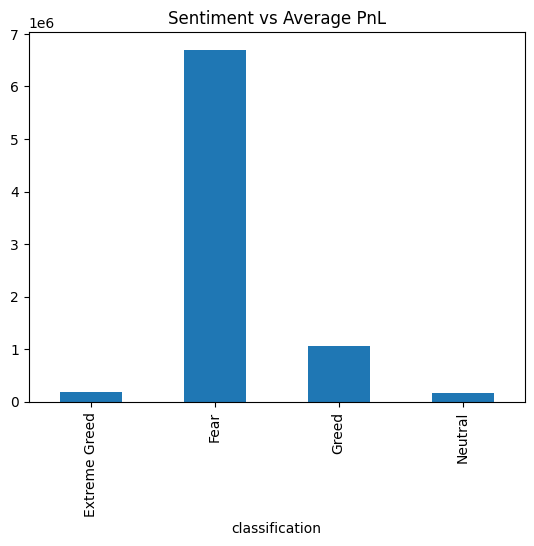

In [106]:
# Creating a bar chart to compare average PnL across different sentiment categories (Fear vs Greed)
# This visualization helps identify how market sentiment impacts trading performance

import matplotlib.pyplot as plt

merged_daily.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Sentiment vs Average PnL")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

In [107]:
daily_pnl = merged_df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [108]:
# Calculating daily PnL for each account by summing Closed PnL per date and account
# This helps analyze individual trader performance on a daily basis

daily_pnl = merged_df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()

# Displaying first few rows of the result
daily_pnl.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [109]:
# Counting number of trades executed each day
# This helps analyze trading activity over time

trades_per_day = merged_df.groupby('date').size().reset_index(name='num_trades')

# Displaying first few rows
trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [110]:
# Creating a 'win' column: True if trade profit (Closed PnL) is positive
merged_df['win'] = merged_df['Closed PnL'] > 0

# Calculating overall win rate (proportion of profitable trades)
win_rate = merged_df['win'].mean()

# Displaying the result
print("Win Rate:", win_rate)

Win Rate: 0.4203502602258728


In [111]:
# Calculating proportion of long vs short trades
# normalize=True converts counts into percentage distribution

long_short_ratio = merged_df['Side'].value_counts(normalize=True)

# Displaying long/short ratio
long_short_ratio

Side
SELL    0.52037
BUY     0.47963
Name: proportion, dtype: float64


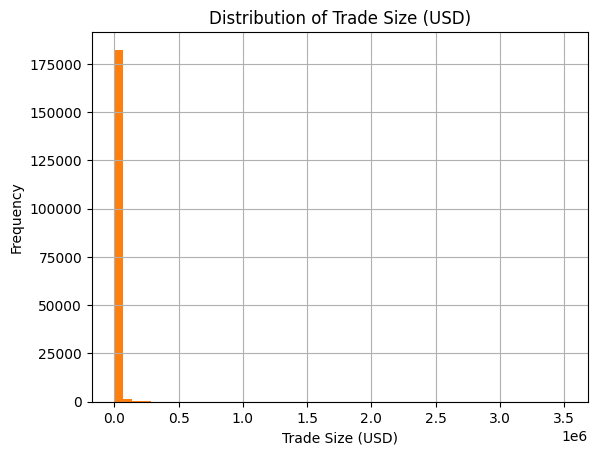

In [136]:
merged_df['Size USD'].hist(bins=50)# Plotting histogram of trade sizes (Size USD)
# This shows the distribution of trade amounts across all trades

merged_df['Size USD'].hist(bins=50)
plt.title("Distribution of Trade Size (USD)")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Frequency")
plt.show()

In [114]:
# Analyzing performance by sentiment (Fear vs Greed)
# mean → average PnL, median → typical PnL, count → number of days

analysis_1 = merged_daily.groupby('classification')['Closed PnL'].agg(['mean','median','count'])

analysis_1

,mean,median,count
classification,,,
Extreme Greed,1.769655e+05,1.769655e+05,1
Fear,6.699925e+06,6.699925e+06,1
Greed,1.063206e+06,1.555034e+02,3
Neutral,1.587424e+05,1.587424e+05,1


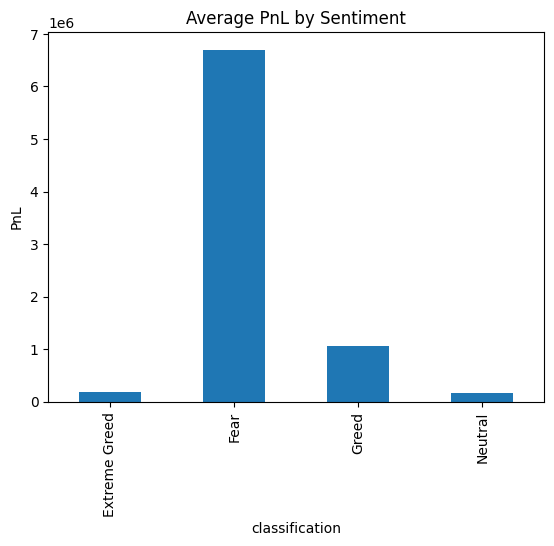

In [115]:
# Plotting average PnL for each sentiment category (Fear vs Greed)
# This helps visually compare how performance varies with market sentiment

merged_daily.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL")
plt.show()

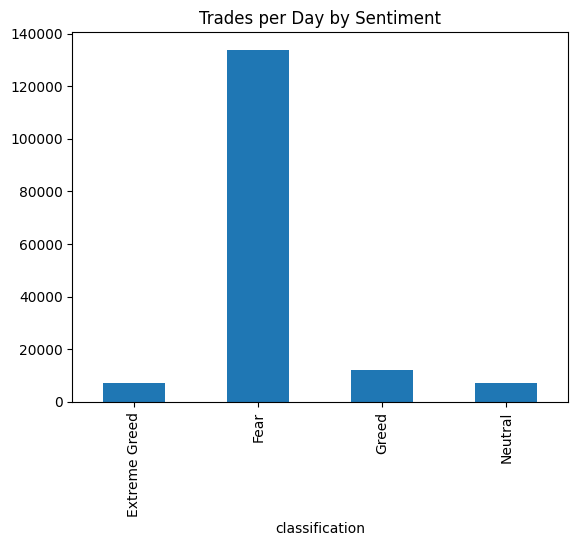

In [118]:
# Calculating number of trades per day for each sentiment (Fear vs Greed)
# This helps analyze how trading activity changes with market sentiment

trade_freq = merged_df.groupby(['date','classification']).size().reset_index(name='trades')

# Calculating average number of trades per day for each sentiment
trade_freq.groupby('classification')['trades'].mean()

# Visualizing average trades per day by sentiment
trade_freq.groupby('classification')['trades'].mean().plot(kind='bar')
plt.title("Trades per Day by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trades per Day")
plt.show()

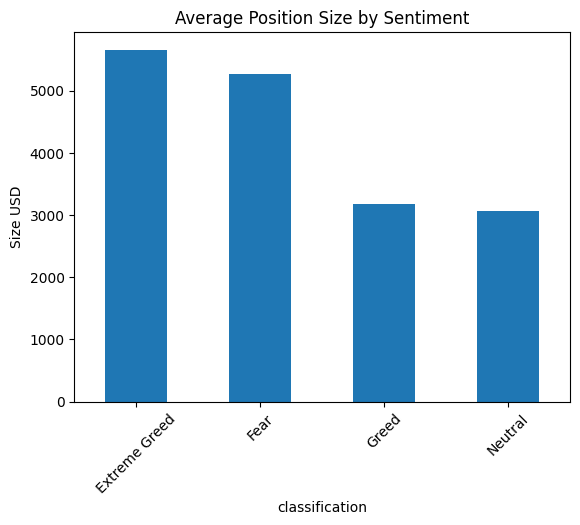

In [123]:
# Plotting average position size (Size USD) for each sentiment category
# This helps understand how trade size varies between Fear and Greed market conditions

merged_df.groupby('classification')['Size USD'].mean().plot(kind='bar')

plt.title("Average Position Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Size USD")
plt.xticks(rotation=45)
plt.show()

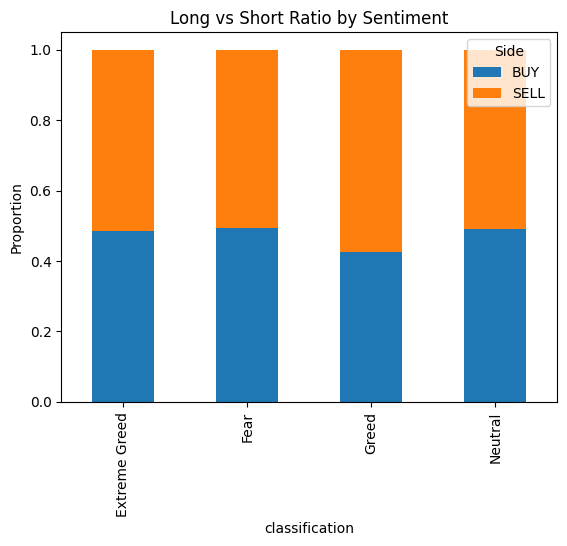

In [128]:
# Creating a crosstab to calculate proportion of Long vs Short trades for each sentiment
# normalize='index' converts counts into row-wise proportions

long_short = pd.crosstab(merged_df['classification'], merged_df['Side'], normalize='index')

# Plotting stacked bar chart to compare long/short distribution across sentiments
long_short.plot(kind='bar', stacked=True)

plt.title("Long vs Short Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Proportion")
plt.show()

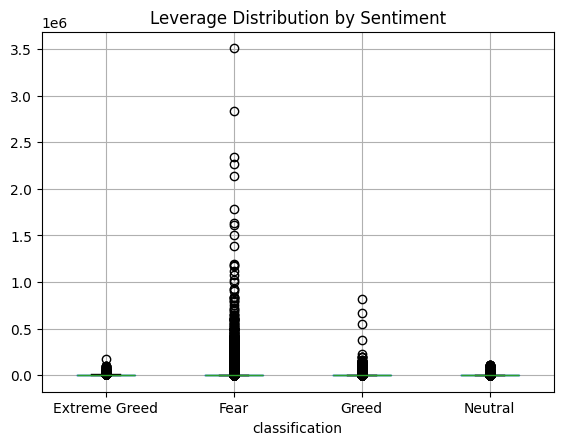

In [129]:
# Creating a boxplot to visualize distribution of trade size (Size USD) by sentiment
# This helps compare variability, median, and outliers between Fear and Greed days

merged_df.boxplot(column='Size USD', by='classification')

plt.title("Trade Size Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Size USD")
plt.suptitle('')  # Removes default subtitle
plt.show()

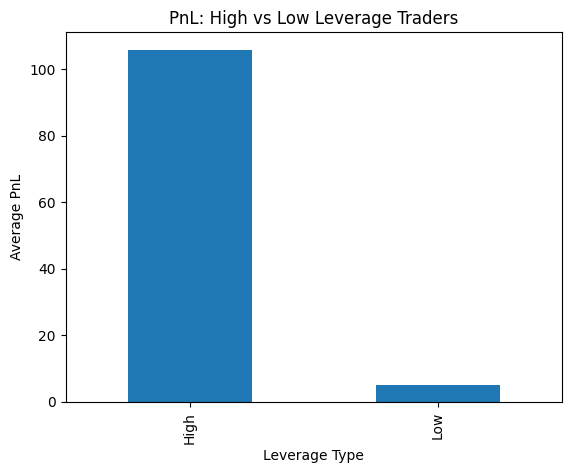

In [139]:
# Splitting trades into High vs Low leverage based on median trade size (threshold)
threshold = merged_df['Size USD'].median()

# Labeling each trade as 'High' or 'Low' leverage
merged_df['leverage_type'] = merged_df['Size USD'].apply(lambda x: 'High' if x > threshold else 'Low')

# Comparing average PnL between High and Low leverage groups
merged_df.groupby('leverage_type')['Closed PnL'].mean().plot(kind='bar')

plt.title("PnL: High vs Low Leverage Traders")
plt.xlabel("Leverage Type")
plt.ylabel("Average PnL")
plt.show()

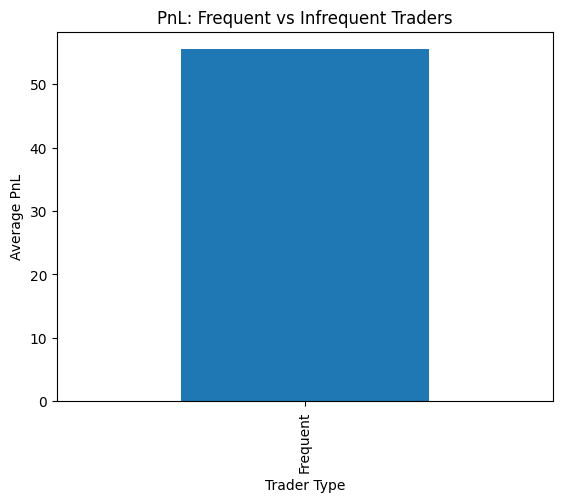

In [138]:
# Counting number of trades per account to identify trading frequency
trade_count = merged_df['Account'].value_counts()

# Classifying traders as 'Frequent' or 'Infrequent' based on threshold (50 trades)
merged_df['trader_type'] = merged_df['Account'].map(
    lambda x: 'Frequent' if trade_count[x] > 50 else 'Infrequent'
)

# Comparing average PnL between Frequent and Infrequent traders
merged_df.groupby('trader_type')['Closed PnL'].mean().plot(kind='bar')

plt.title("PnL: Frequent vs Infrequent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Average PnL")
plt.show()

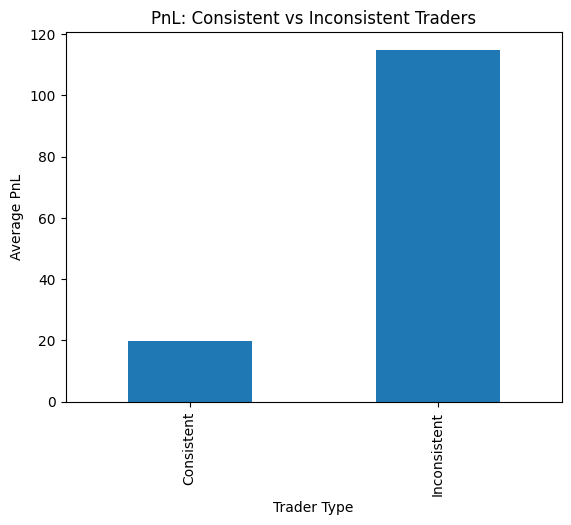

In [143]:
# Measuring trading consistency using standard deviation of PnL per account
consistency = merged_df.groupby('Account')['Closed PnL'].std().reset_index()

# Defining threshold using median standard deviation
threshold = consistency['Closed PnL'].median()

# Classifying traders based on consistency
consistency['type'] = consistency['Closed PnL'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

# Mapping consistency type directly to main dataset (avoids merge error)
merged_df['type'] = merged_df['Account'].map(
    consistency.set_index('Account')['type']
)

# Comparing average PnL between Consistent and Inconsistent traders
merged_df.groupby('type')['Closed PnL'].mean().plot(kind='bar')

plt.title("PnL: Consistent vs Inconsistent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Average PnL")
plt.show()